# Student Performance Analysis

**Dataset:** `StudentsPerformance.csv`


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load the original dataset
file_path = "/content/StudentsPerformance.csv"
df = pd.read_csv("C:\\Users\\David\\Downloads\\StudentsPerformance.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Data Quality — Structure and Basic Validation

The first step is to understand the number of records, columns, data types, and whether the dataset contains unexpected structure problems.

In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 1000
Columns: 8

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types:


,dtype
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64



Duplicate rows: 0


### Missing Values

Missing values are checked for every column. If there are no missing values, no filling is necessary and the original data remains untouched.

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

display(missing_report)

,missing_count,missing_percent
gender,0,0.00
race/ethnicity,0,0.00
parental level of education,0,0.00
lunch,0,0.00
test preparation course,0,0.00
math score,0,0.00
reading score,0,0.00
writing score,0,0.00


**Insight:** The dataset contains **0 missing values in all 8 columns**, so there is no null-filling operation required for the current file.

### Categorical Validation

We inspect all categorical values for unexpected labels, whitespace problems, and inconsistent capitalization.

In [8]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    values = df[col].astype(str)
    print(f"\n{col}")
    print("Unique values:", values.nunique())
    print("Leading/trailing whitespace:", values.str.strip().ne(values).sum())
    print("Values:")
    display(values.value_counts().rename("count").to_frame())


gender
Unique values: 2
Leading/trailing whitespace: 0
Values:


,count
gender,
female,518
male,482



race/ethnicity
Unique values: 5
Leading/trailing whitespace: 0
Values:


,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89



parental level of education
Unique values: 6
Leading/trailing whitespace: 0
Values:


,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59



lunch
Unique values: 2
Leading/trailing whitespace: 0
Values:


,count
lunch,
standard,645
free/reduced,355



test preparation course
Unique values: 2
Leading/trailing whitespace: 0
Values:


,count
test preparation course,
none,642
completed,358


**Insight:** The categorical fields contain a small, consistent set of labels. No leading/trailing whitespace issue was found in the current data.

### Numeric Validation

Student scores should logically be between 0 and 100. We validate every score without deleting any observation.

In [9]:
score_cols = ["math score", "reading score", "writing score"]

validation_rows = []
for col in score_cols:
    validation_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "min": df[col].min(),
        "max": df[col].max(),
        "invalid_below_0": (df[col] < 0).sum(),
        "invalid_above_100": (df[col] > 100).sum(),
        "nulls": df[col].isna().sum()
    })

numeric_validation = pd.DataFrame(validation_rows)
display(numeric_validation)

,column,dtype,min,max,invalid_below_0,invalid_above_100,nulls
0,math score,int64,0,100,0,0,0
1,reading score,int64,17,100,0,0,0
2,writing score,int64,10,100,0,0,0


**Insight:** All three score columns are numeric and all observed values are within the valid 0–100 score range. There are **no invalid score values**.

## 2. Intake Overview — Categorical and Numerical Statistics

In [10]:
print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", score_cols)

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts().rename("count").to_frame())

print("\nNumerical descriptive statistics:")
display(df[score_cols].describe().T)

Categorical columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Numerical columns: ['math score', 'reading score', 'writing score']

--- gender ---


,count
gender,
female,518
male,482



--- race/ethnicity ---


,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89



--- parental level of education ---


...

,count
lunch,
standard,645
free/reduced,355



--- test preparation course ---


,count
test preparation course,
none,642
completed,358



Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
math score,"1,000.00",66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,"1,000.00",69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,"1,000.00",68.05,15.20,10.00,57.75,69.00,79.00,100.00


### Derived Performance Measures

For analysis only, we create an `average_score` and `total_score`. These are new analytical fields; the original columns and rows are not changed.

In [11]:
analysis_df = df.copy()

analysis_df["average_score"] = analysis_df[score_cols].mean(axis=1)
analysis_df["total_score"] = analysis_df[score_cols].sum(axis=1)

analysis_df["passed_all"] = (analysis_df[score_cols] >= 50).all(axis=1)

analysis_df["performance_band"] = pd.cut(
    analysis_df["average_score"],
    bins=[-1, 49.999, 69.999, 84.999, 100],
    labels=["Below 50", "50-69", "70-84", "85-100"]
)

display(analysis_df[score_cols + ["average_score", "total_score"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
math score,"1,000.00",66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,"1,000.00",69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,"1,000.00",68.05,15.20,10.00,57.75,69.00,79.00,100.00
average_score,"1,000.00",67.77,14.26,9.00,58.33,68.33,77.67,100.00
total_score,"1,000.00",203.31,42.77,27.00,175.00,205.00,233.00,300.00


### Outlier Study

Outliers are detected with the IQR rule. **Outliers are not removed** because a very low or high student score can be a genuine observation.

In [12]:
outlier_report = []

for col in score_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    outlier_report.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum()
    })

outlier_report = pd.DataFrame(outlier_report)
display(outlier_report)

outlier_masks = []
for col in score_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_masks.append((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr))

any_outlier = np.logical_or.reduce(outlier_masks)
print("Rows with an outlier in at least one score:", any_outlier.sum())

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,math score,57.00,77.00,20.00,27.00,107.00,8
1,reading score,59.00,79.00,20.00,29.00,109.00,6
2,writing score,57.75,79.00,21.25,25.88,110.88,5


Rows with an outlier in at least one score: 12


**Insight:** The IQR rule flags a small number of unusually low scores. These observations are still valid because they remain within the 0–100 scoring range. They should be **flagged for investigation, not deleted**.

## 3. Important Questions — Answers From the Data

### Q1. What is the overall performance level?

In [13]:
overall = {
    "Average math": df["math score"].mean(),
    "Average reading": df["reading score"].mean(),
    "Average writing": df["writing score"].mean(),
    "Average across all subjects": analysis_df["average_score"].mean(),
    "Students passing all 3 at >= 50": analysis_df["passed_all"].sum(),
    "Pass-all percentage": analysis_df["passed_all"].mean() * 100
}
display(pd.Series(overall).to_frame("value"))

,value
Average math,66.09
Average reading,69.17
Average writing,68.05
Average across all subjects,67.77
Students passing all 3 at >= 50,812.00
Pass-all percentage,81.20


### Q2. Which subject is strongest and which is weakest?

In [14]:
subject_means = df[score_cols].mean().sort_values(ascending=False)
display(subject_means.to_frame("average_score"))

,average_score
reading score,69.17
writing score,68.05
math score,66.09


**Answer:** Reading has the highest average score, while math has the lowest average score. Writing is between them.

### Q3. Does test preparation relate to better performance?

In [15]:
prep_summary = (
    analysis_df.groupby("test preparation course", observed=True)
    .agg(
        students=("average_score", "size"),
        average_score=("average_score", "mean"),
        math=("math score", "mean"),
        reading=("reading score", "mean"),
        writing=("writing score", "mean"),
        pass_all_pct=("passed_all", "mean")
    )
)

prep_summary["pass_all_pct"] *= 100
display(prep_summary.sort_values("average_score", ascending=False))

,students,average_score,math,reading,writing,pass_all_pct
test preparation course,,,,,,
completed,358,72.67,69.70,73.89,74.42,89.94
none,642,65.04,64.08,66.53,64.50,76.32


**Answer:** Students who completed the test preparation course have a higher average score and a higher percentage passing all three subjects than students with no preparation course. This is an observed association in this dataset, not proof that the course alone caused the difference.

### Q4. Which student group has the highest and lowest average performance?

In [16]:
for col in [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch"
]:
    summary = (
        analysis_df.groupby(col, observed=True)["average_score"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n{col}")
    display(summary)


gender


,count,mean
gender,,
female,518,69.57
male,482,65.84



race/ethnicity


,count,mean
race/ethnicity,,
group E,140,72.75
group D,262,69.18
group C,319,67.13
group B,190,65.47
group A,89,62.99



parental level of education


,count,mean
parental level of education,,
master's degree,59,73.60
bachelor's degree,118,71.92
associate's degree,222,69.57
some college,226,68.48
some high school,179,65.11
high school,196,63.10



lunch


,count,mean
lunch,,
standard,645,70.84
free/reduced,355,62.20


### Q5. Is there a performance difference by lunch category?

In [17]:
lunch_summary = (
    analysis_df.groupby("lunch", observed=True)
    .agg(
        students=("average_score", "size"),
        average_score=("average_score", "mean"),
        math=("math score", "mean"),
        reading=("reading score", "mean"),
        writing=("writing score", "mean"),
        pass_all_pct=("passed_all", "mean")
    )
)
lunch_summary["pass_all_pct"] *= 100
display(lunch_summary)

,students,average_score,math,reading,writing,pass_all_pct
lunch,,,,,,
free/reduced,355,62.20,58.92,64.65,63.02,68.73
standard,645,70.84,70.03,71.65,70.82,88.06


**Answer:** The standard-lunch group has a higher average performance and higher all-subject pass rate than the free/reduced-lunch group. The dataset alone cannot establish the reason or causality.

## 4. Exploratory Data Analysis — Univariate

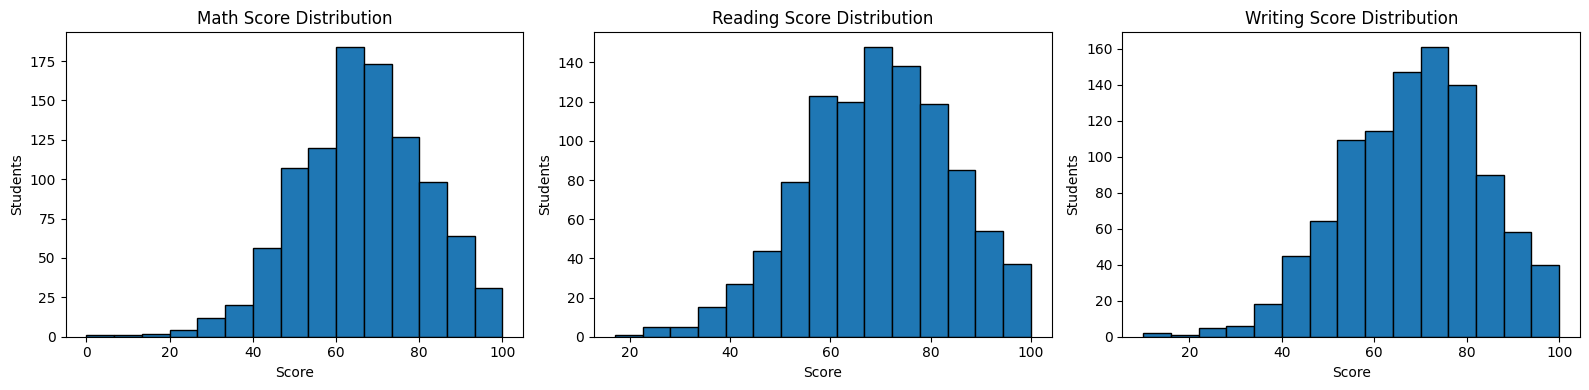

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, score_cols):
    ax.hist(df[col], bins=15, edgecolor="black")
    ax.set_title(f"{col.title()} Distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Students")

plt.tight_layout()
plt.show()

C:\Users\David\AppData\Local\Temp\ipykernel_22892\2767708948.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c] for c in score_cols], labels=["Math", "Reading", "Writing"])


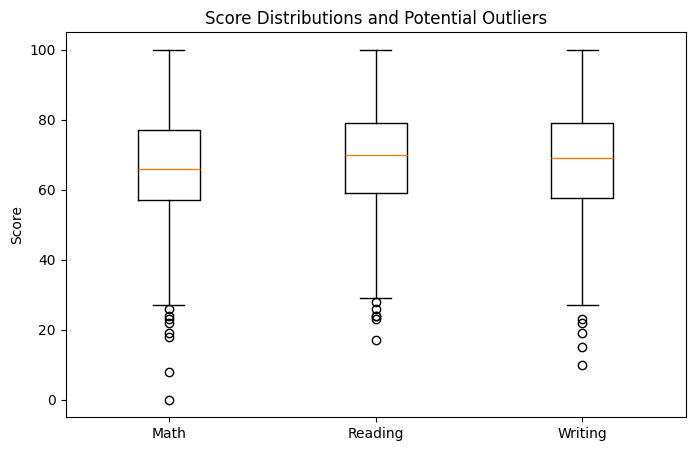

In [19]:
plt.figure(figsize=(8, 5))
plt.boxplot([df[c] for c in score_cols], labels=["Math", "Reading", "Writing"])
plt.ylabel("Score")
plt.title("Score Distributions and Potential Outliers")
plt.show()

### Performance Bands

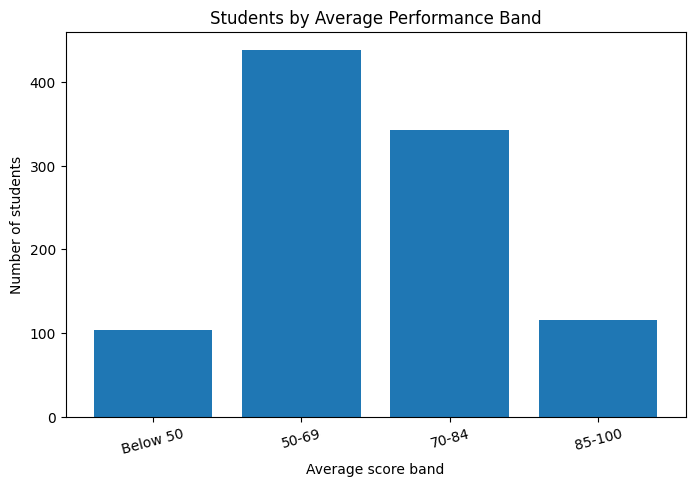

,students
performance_band,
Below 50,103
50-69,438
70-84,343
85-100,116


In [20]:
band_counts = analysis_df["performance_band"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(band_counts.index.astype(str), band_counts.values)
plt.title("Students by Average Performance Band")
plt.xlabel("Average score band")
plt.ylabel("Number of students")
plt.xticks(rotation=15)
plt.show()

display(band_counts.rename("students").to_frame())

## 5. Bivariate EDA

We compare performance across gender, race/ethnicity, parental education, lunch, and test preparation.

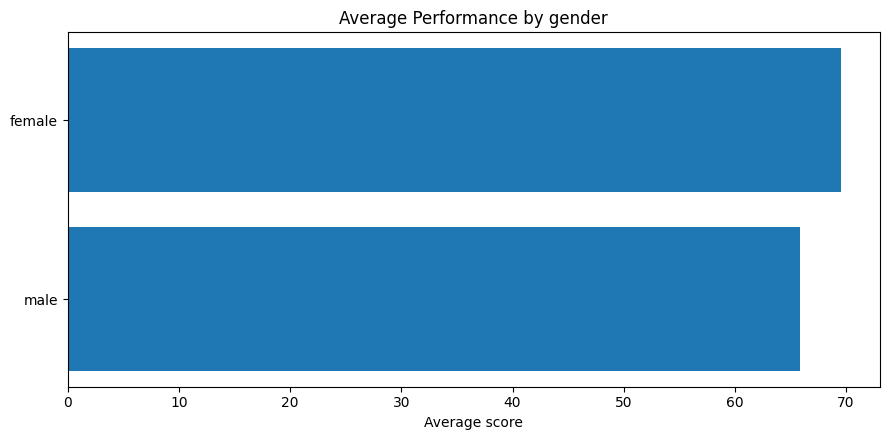

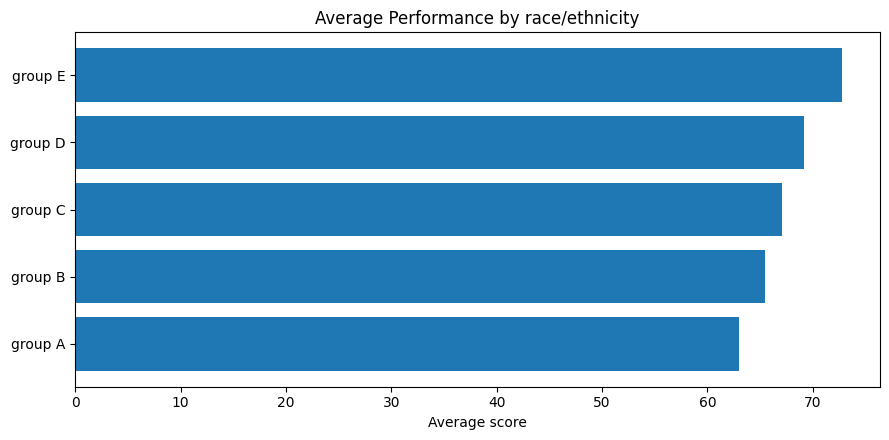

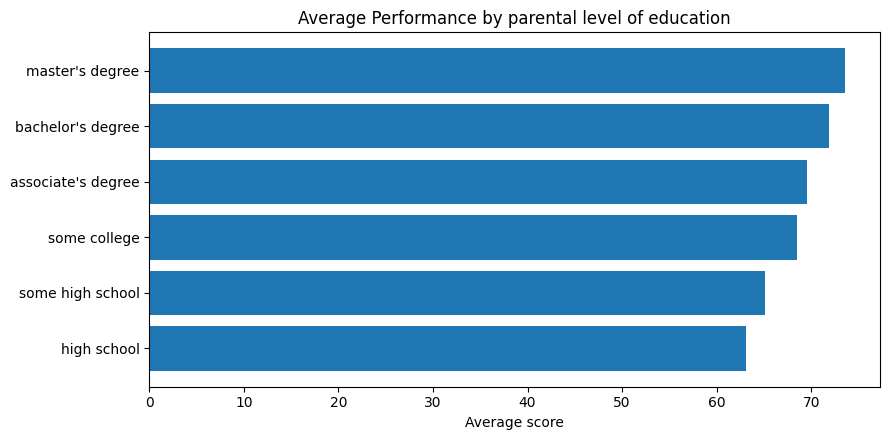

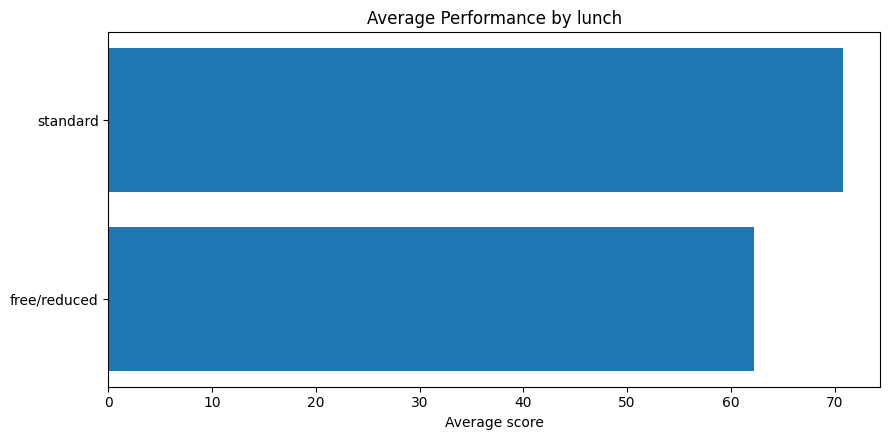

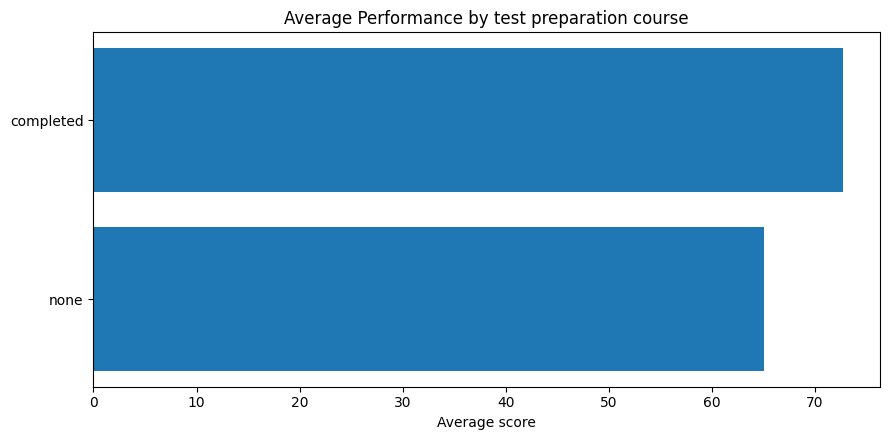

In [21]:
group_cols = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for col in group_cols:
    summary = analysis_df.groupby(col, observed=True)["average_score"].mean().sort_values()
    plt.figure(figsize=(9, 4.5))
    plt.barh(summary.index.astype(str), summary.values)
    plt.xlabel("Average score")
    plt.title(f"Average Performance by {col}")
    plt.tight_layout()
    plt.show()

### Subject Comparison by Major Factors

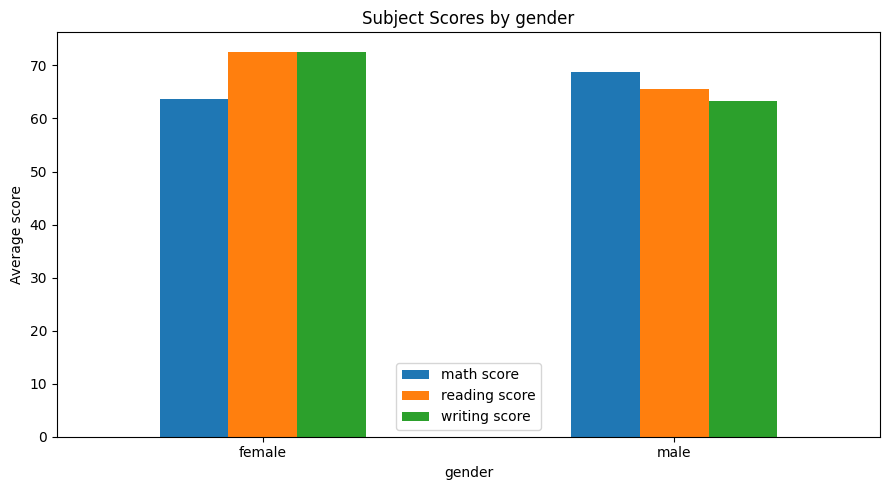

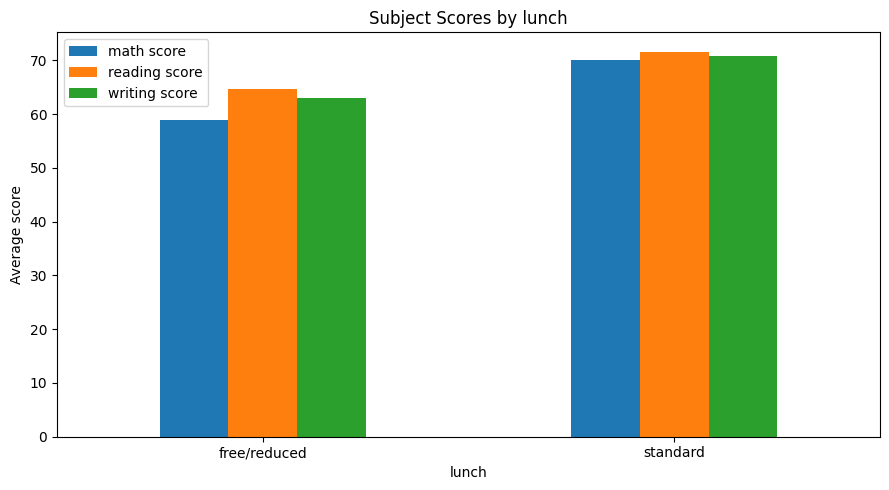

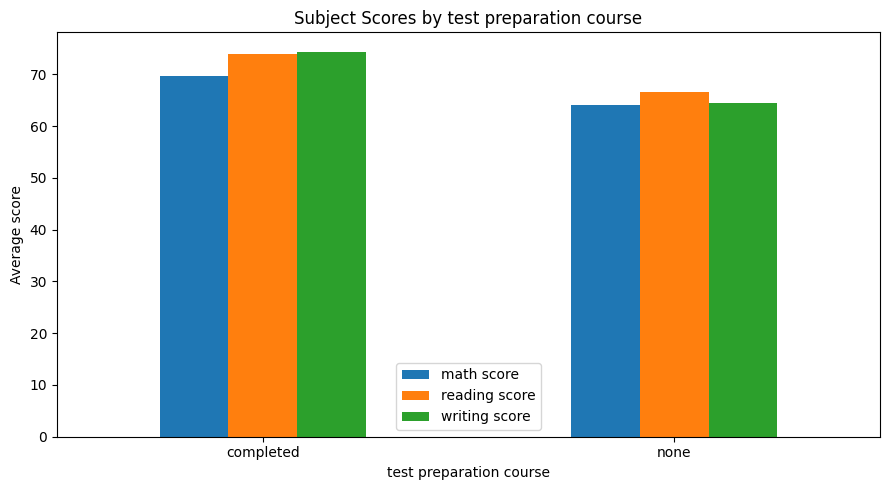

In [22]:
for col in ["gender", "lunch", "test preparation course"]:
    summary = analysis_df.groupby(col, observed=True)[score_cols].mean()
    summary.plot(kind="bar", figsize=(9, 5))
    plt.ylabel("Average score")
    plt.title(f"Subject Scores by {col}")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 6. Multivariate EDA

We examine combinations of factors instead of looking at each variable separately.

test preparation course,completed,none
lunch,,
free/reduced,67.76,58.95
standard,75.51,68.30


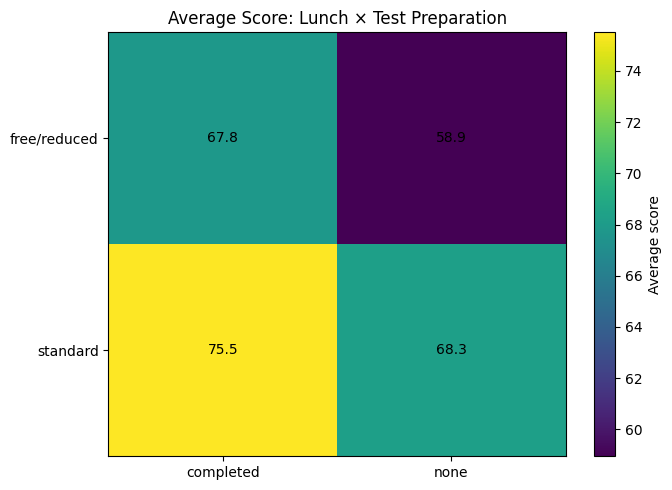

In [23]:
# Lunch x test preparation
pivot_lunch_prep = analysis_df.pivot_table(
    index="lunch",
    columns="test preparation course",
    values="average_score",
    aggfunc="mean"
)

display(pivot_lunch_prep.round(2))

plt.figure(figsize=(7, 5))
plt.imshow(pivot_lunch_prep.values, aspect="auto")
plt.colorbar(label="Average score")
plt.xticks(range(len(pivot_lunch_prep.columns)), pivot_lunch_prep.columns)
plt.yticks(range(len(pivot_lunch_prep.index)), pivot_lunch_prep.index)
plt.title("Average Score: Lunch × Test Preparation")

for i in range(pivot_lunch_prep.shape[0]):
    for j in range(pivot_lunch_prep.shape[1]):
        plt.text(j, i, f"{pivot_lunch_prep.iloc[i,j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

test preparation course,completed,none
gender,,
female,74.45,66.88
male,70.78,63.04


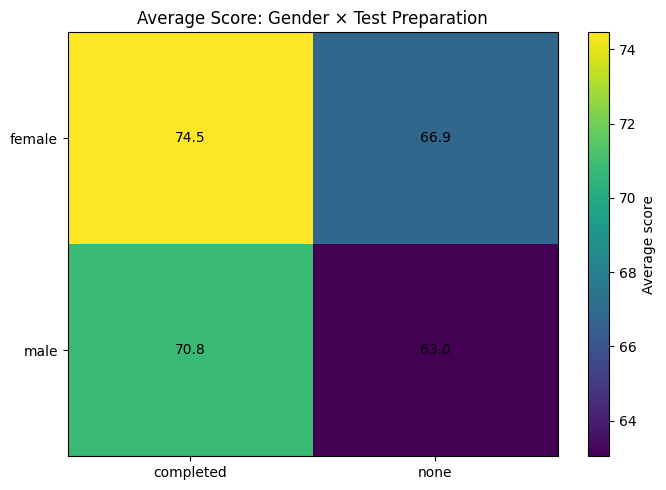

In [24]:
# Gender x test preparation
pivot_gender_prep = analysis_df.pivot_table(
    index="gender",
    columns="test preparation course",
    values="average_score",
    aggfunc="mean"
)

display(pivot_gender_prep.round(2))

plt.figure(figsize=(7, 5))
plt.imshow(pivot_gender_prep.values, aspect="auto")
plt.colorbar(label="Average score")
plt.xticks(range(len(pivot_gender_prep.columns)), pivot_gender_prep.columns)
plt.yticks(range(len(pivot_gender_prep.index)), pivot_gender_prep.index)
plt.title("Average Score: Gender × Test Preparation")

for i in range(pivot_gender_prep.shape[0]):
    for j in range(pivot_gender_prep.shape[1]):
        plt.text(j, i, f"{pivot_gender_prep.iloc[i,j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

Correlation shows how strongly subject scores move together. It does not prove causation.

,math score,reading score,writing score,average_score
math score,1.00,0.82,0.80,0.92
reading score,0.82,1.00,0.95,0.97
writing score,0.80,0.95,1.00,0.97
average_score,0.92,0.97,0.97,1.00


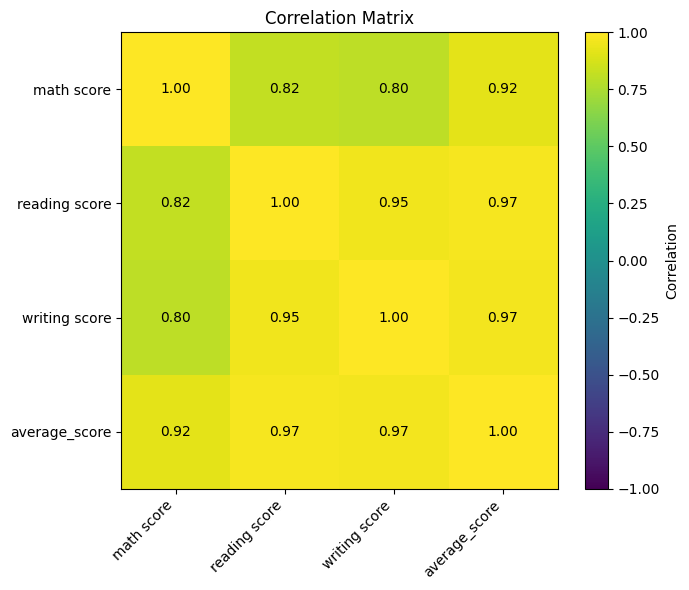

In [25]:
corr = analysis_df[score_cols + ["average_score"]].corr()

display(corr.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

**Insight:** Reading and writing are very strongly related in this dataset. Math is also strongly related to the other subjects, but slightly less strongly than reading and writing are related to each other.

## 8. Performance Increasing or Dropping — What Can and Cannot Be Concluded?

The requested sales-style question is adapted to student performance.

- **Increasing/dropping over time:** Cannot be measured because the dataset has no date, semester, year, or student-attempt-time column.
- **Where performance is higher/lower:** Can be measured by the available categorical variables.
- **Why performance differs:** The dataset can identify associations with test preparation, lunch category, parental education, gender, and race/ethnicity, but it cannot prove causal reasons.

In [26]:
# Ranked observed differences
factors = {
    "gender": "average_score",
    "race/ethnicity": "average_score",
    "parental level of education": "average_score",
    "lunch": "average_score",
    "test preparation course": "average_score"
}

for factor, metric in factors.items():
    result = (
        analysis_df.groupby(factor, observed=True)[metric]
        .mean()
        .sort_values(ascending=False)
    )
    print(f"\n{factor}: highest = {result.index[0]} ({result.iloc[0]:.2f}), "
          f"lowest = {result.index[-1]} ({result.iloc[-1]:.2f})")


gender: highest = female (69.57), lowest = male (65.84)

race/ethnicity: highest = group E (72.75), lowest = group A (62.99)

parental level of education: highest = master's degree (73.60), lowest = high school (63.10)

lunch: highest = standard (70.84), lowest = free/reduced (62.20)

test preparation course: highest = completed (72.67), lowest = none (65.04)


## 9. Data Cleaning — No Data Removal

The current dataset has no missing values, no duplicate rows, and no out-of-range scores. Therefore, **no records need to be removed or filled**.

If future versions of the same dataset contain missing values, recommended logic is:

1. **Categorical fields:** use the most frequent category only when there is strong evidence that it is appropriate; otherwise flag the missing value as `Unknown`.
2. **Score fields:** use a defensible group-based median (for example, within the same relevant student group) rather than deleting the student.
3. **Invalid scores outside 0–100:** flag them for source verification and retain the original value in the raw dataset.
4. **Duplicates:** investigate whether they are true duplicate student records before changing anything. Never automatically delete without a business/data rule.
5. **Outliers:** retain valid 0–100 scores and flag them for review.

### Important
The original `df` remains unchanged throughout this notebook.

In [27]:
# Final data-quality check — original dataframe
final_quality = {
    "rows": len(df),
    "columns": len(df.columns),
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "invalid_score_cells": int(
        ((df[score_cols] < 0) | (df[score_cols] > 100)).sum().sum()
    )
}

display(pd.Series(final_quality).to_frame("value"))

,value
rows,1000
columns,8
missing_cells,0
duplicate_rows,0
invalid_score_cells,0


## 10. Executive Summary — Evidence From This Dataset

### Data quality
- **1,000 students and 8 original columns**.
- **0 missing values**.
- **0 exact duplicate rows**.
- **0 invalid score values** outside 0–100.
- A small number of low-score observations are statistical outliers, but they are valid scores and were retained.

### Performance
- Overall mean score across the three subjects: **67.77**.
- Mean math score: **66.09**.
- Mean reading score: **69.17**.
- Mean writing score: **68.05**.
- **812 of 1,000 students (81.2%)** scored at least 50 in all three subjects.

### Strong observed differences
- Students who **completed test preparation** have a higher mean average score (**72.67**) than those with **no preparation** (**65.04**).
- The **standard-lunch** group has a higher mean average score (**70.84**) than the **free/reduced-lunch** group (**62.20**).
- The highest average score by race/ethnicity is **group E (72.75)**; the lowest is **group A (62.99)**.
- The highest average by parental education is **master's degree (73.60)**; the lowest is **high school (63.10)**.
- Female students have a higher average overall score than male students in this dataset (**69.57 vs 65.84**).

### Key analytical caution
These are **associations in this dataset**, not causal conclusions. For example, the data does not prove that test preparation itself caused the higher scores.

### Trend limitation
There is **no time variable**, so the dataset cannot answer whether student performance is increasing or dropping over time, nor can it identify *when* a trend changed.

# Final Conclusion

The strongest actionable pattern in the available data is the performance gap associated with **test preparation** and **lunch category**, with additional differences across parental education, race/ethnicity, and gender.

For a true performance trend analysis, the next dataset should include a time dimension such as **exam date, semester, academic year, or repeated student assessments**. That would allow analysis of **when performance increases/decreases and where the decline occurs**.

No original student records were removed in this analysis.